In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from lifelines.datasets import load_lung
import pandas as pd

df = load_lung()
df.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


In [2]:
df[['time', 'status']].describe()
print("\nStatus value counts:")
print(df['status'].value_counts())


Status value counts:
status
1    165
0     63
Name: count, dtype: int64


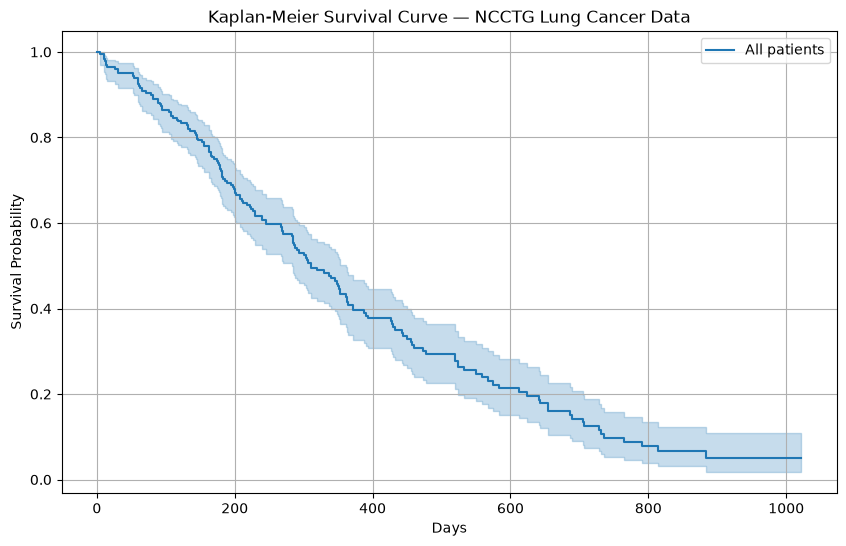

In [3]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# status: 1 = censored, 2 = death. lifelines needs event=True for death, False for censored.
event_observed = df['status'] == 1

kmf.fit(durations=df['time'], event_observed=event_observed, label="All patients")

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve — NCCTG Lung Cancer Data")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

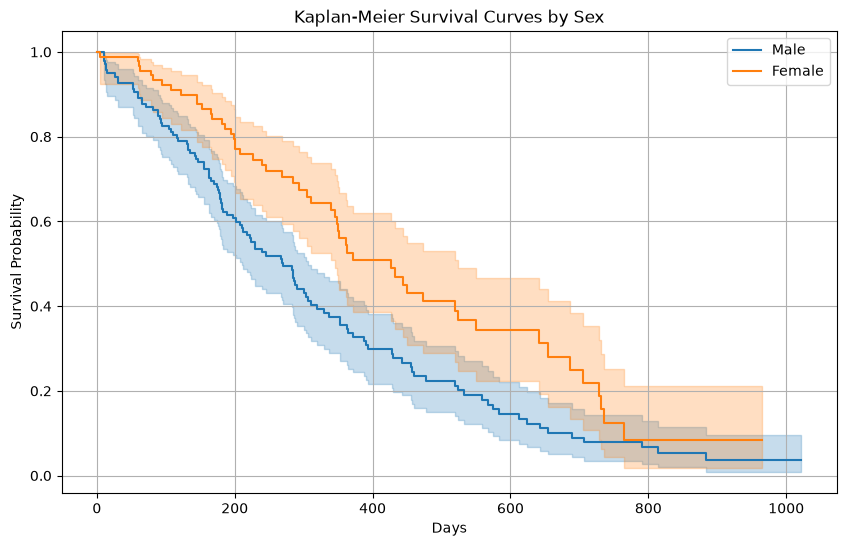

In [4]:
kmf_male = KaplanMeierFitter()
kmf_female = KaplanMeierFitter()

# In this dataset: sex == 1 is male, sex == 2 is female
male_mask = df['sex'] == 1
female_mask = df['sex'] == 2

kmf_male.fit(df['time'][male_mask], event_observed=event_observed[male_mask], label="Male")
kmf_female.fit(df['time'][female_mask], event_observed=event_observed[female_mask], label="Female")

plt.figure(figsize=(10, 6))
ax = kmf_male.plot_survival_function()
kmf_female.plot_survival_function(ax=ax)
plt.title("Kaplan-Meier Survival Curves by Sex")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

In [5]:
from lifelines.statistics import logrank_test

results = logrank_test(
    df['time'][male_mask], df['time'][female_mask],
    event_observed_A=event_observed[male_mask],
    event_observed_B=event_observed[female_mask]
)

print(f"Test statistic: {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.4f}")

Test statistic: 10.3267
p-value: 0.0013


In [6]:
from lifelines import CoxPHFitter

# Build a clean dataframe with the columns Cox regression needs
cox_df = df[['time', 'status', 'age', 'sex', 'ph.ecog']].copy()
cox_df['event'] = cox_df['status'] == 1
cox_df = cox_df.drop(columns=['status']).dropna()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time', event_col='event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 227 total observations, 63 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 227
number of events observed = 164
   partial log-likelihood = -729.23
         time fit was run = 2026-09-02 20:09:31 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sex       -0.55      0.58      0.17           -0.88           -0.22                0.41                0.80
ph.ecog    0.46      1.59      0.11            0.24            0.69                1.27                1.99

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.19   0.23      2.11
sex          0.00 -3.29 <0.005      9.99
ph.ecog      0.00  4.08 <0.005     14.46
---
Concordance = 0.64
Partial AIC = 1464.46
log-likelihood ratio test = 30.50 on 3 df
-log2(p) of ll-ratio test = 19.82


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.7302)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8656)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1302)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1189)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1458)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1412)'>]]

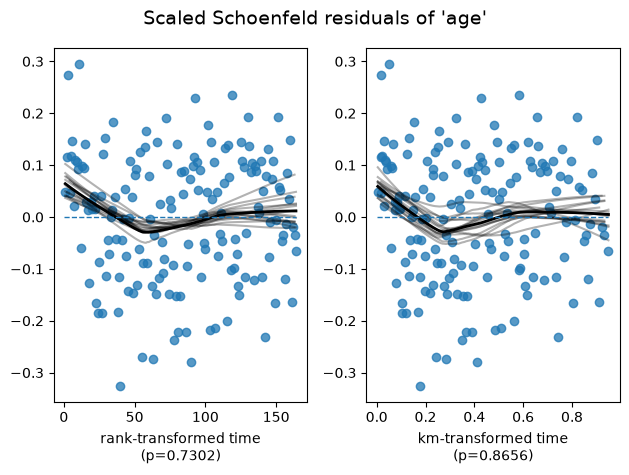

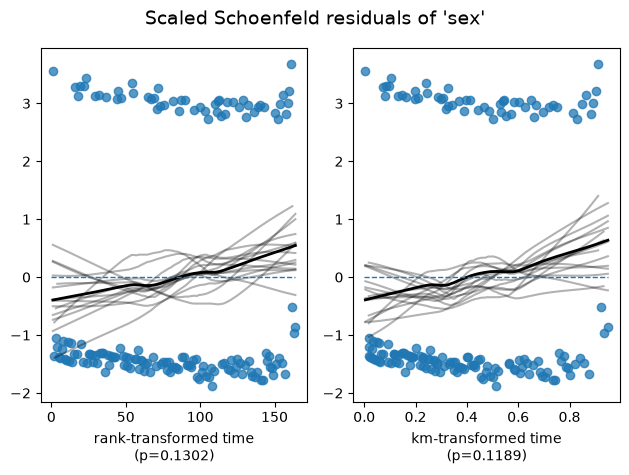

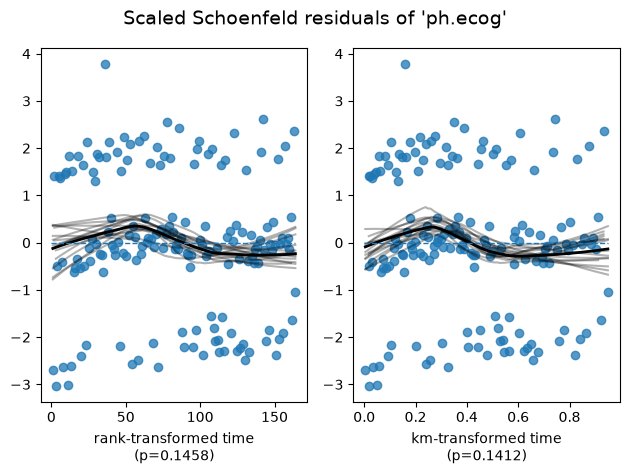

In [7]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)